## Import Libraries  

In [58]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import squarify
from wordcloud import WordCloud

 ## Fetch Data From MySQL Database

In [ ]:
connection = mysql.connector.connect(
    host = '',
    user = '',
    password = '',
    database =''
)

In [60]:
query = "select * from cyber_attacks"

In [61]:
df = pd.read_sql(query , connection)

C:\Users\elmnshawy\AppData\Local\Temp\ipykernel_4332\162786456.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query , connection)


## Data Representation

In [62]:
df.head()

,ID,Title,Category,Attack_Type,Scenario_Description,Tools_Used,Attack_Steps_,Target_Type,Vulnerability,MITRE_Technique,Impact,Detection_Method,Solution,Tags,Source,Unnamed:_15
0,1,Authentication Bypass via SQL Injection,Mobile Security,SQL Injection (SQLi),A login form fails to validate or sanitize inp...,"Browser, Burp Suite, SQLMap",1. Reconnaissance: Find a login form on the we...,"Web Login Portals (e.g., banking, admin dashbo...",Unsanitized input fields in SQL queries,"T1078 (Valid Accounts), T1190 (Exploit Public-...","Full account takeover, data theft, privilege e...","Web server logs, anomaly detection (e.g., logi...","Use prepared statements, Sanitize inputs, Limi...","SQLi, Authentication Bypass, Web Security, OWA...","OWASP, MITRE ATT&CK, DVWA",NaN
1,2,Union-Based SQL Injection,AI Agents & LLM Exploits,SQL Injection,This attack occurs when a hacker uses the SQL ...,"SQLMap, Burp Suite, Havij, Browser Developer T...",1. Identify User Input Points: Attacker finds ...,"Web Applications, Login Pages, Search Forms",Improperly filtered input fields that allow SQ...,T1190 – Exploit Public-Facing Application,"Data leakage, Credential theft, Account takeov...",Web Application Firewalls (WAF)Log AnalysisInp...,Use parameterized queries (Prepared Statements...,#SQLInjection #WebSecurity #UnionAttack #OWASP...,"OWASP, MITRE ATT&CK, Acunetix, PortSwigger Web...",NaN
2,3,Error-Based SQL Injection,AI Agents & LLM Exploits,SQL Injection,This attack occurs when an attacker intentiona...,"SQLMap, Burp Suite, Manual Browser Testing, Havij",1. Identify Input Points:Attacker finds a fiel...,"Web Applications, Login Forms, URL Parameters,...",Error message exposure due to lack of input va...,T1190 – Exploit Public-Facing Application,"Information disclosure, Database structure exp...",Review and monitor error logsEnable generic er...,Turn off detailed error messages in production...,#SQLInjection #ErrorLeakage #WebAppSecurity #O...,"OWASP, MITRE ATT&CK, Acunetix, PortSwigger Web...",NaN
3,4,Blind SQL Injection,AI Agents & LLM Exploits,SQL Injection,"In Blind SQL Injection, the attacker doesn’t s...","SQLMap, Burp Suite, sqlninja, Manual Browser T...",1. Find a User Input Point:Attacker finds a pl...,"Web Applications, Login Pages, Search Fields, ...","No error messages, but user input is still pas...",T1190 – Exploit Public-Facing Application,Slow and stealthy data theftFull database comp...,Monitor for slow and repetitive requestsAnalyz...,Use parameterized queries (prepared statements...,#BlindSQLi #TimeBasedSQLi #WebAppSecurity #OWA...,"OWASP, MITRE ATT&CK, Acunetix, PortSwigger, SQ...",NaN
4,5,Second-Order SQL Injection,AI Agents & LLM Exploits,SQL Injection,"In a Second-Order SQL Injection, the attacker ...","Burp Suite, SQLMap, Postman, Browser Dev Tools...",1. Identify Stored Input Fields:The attacker l...,"Web Applications, User Registration Forms, Pro...",Trusting previously stored unvalidated data in...,T1505.003 – SQL Injection,Delayed data theftUnexpected system behaviorSe...,Log monitoring for delayed query failuresTrack...,Sanitize and validate inputs both at entry and...,#SecondOrderSQLi #DelayedInjection #StoredInje...,"OWASP, MITRE ATT&CK, PortSwigger Academy, Acun...",NaN


In [63]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14133 entries, 0 to 14132
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   ID                    14133 non-null  int64
 1   Title                 14133 non-null  str  
 2   Category              14133 non-null  str  
 3   Attack_Type           14133 non-null  str  
 4   Scenario_Description  14133 non-null  str  
 5   Tools_Used            14119 non-null  str  
 6   Attack_Steps_         14133 non-null  str  
 7   Target_Type           14129 non-null  str  
 8   Vulnerability         14115 non-null  str  
 9   MITRE_Technique       14109 non-null  str  
 10  Impact                14130 non-null  str  
 11  Detection_Method      14129 non-null  str  
 12  Solution              14130 non-null  str  
 13  Tags                  14130 non-null  str  
 14  Source                13973 non-null  str  
 15  Unnamed:_15           46 non-null     str  
dtypes: int64(1), st

In [64]:
df.drop(columns=['Unnamed:_15'],inplace=True)

In [65]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14133 entries, 0 to 14132
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   ID                    14133 non-null  int64
 1   Title                 14133 non-null  str  
 2   Category              14133 non-null  str  
 3   Attack_Type           14133 non-null  str  
 4   Scenario_Description  14133 non-null  str  
 5   Tools_Used            14119 non-null  str  
 6   Attack_Steps_         14133 non-null  str  
 7   Target_Type           14129 non-null  str  
 8   Vulnerability         14115 non-null  str  
 9   MITRE_Technique       14109 non-null  str  
 10  Impact                14130 non-null  str  
 11  Detection_Method      14129 non-null  str  
 12  Solution              14130 non-null  str  
 13  Tags                  14130 non-null  str  
 14  Source                13973 non-null  str  
dtypes: int64(1), str(14)
memory usage: 1.6 MB


In [66]:
df.isnull().sum()

ID                        0
Title                     0
Category                  0
Attack_Type               0
Scenario_Description      0
Tools_Used               14
Attack_Steps_             0
Target_Type               4
Vulnerability            18
MITRE_Technique          24
Impact                    3
Detection_Method          4
Solution                  3
Tags                      3
Source                  160
dtype: int64

In [67]:
df = df.dropna()

In [68]:
# df= df[df['Vulnerability'].notna()]

In [69]:
df.isnull().sum().sum()

np.int64(0)

In [70]:
df.duplicated().sum()

np.int64(0)

## Explore Data Analysis 'EDA'

In [71]:
df['Attack_Type'].value_counts()

Attack_Type
Hardware Interface Exploitation    161
Wireless Attacks (Advanced)         95
Dependency Confusion                90
Fuzzer Configuration                75
Malicious Libraries                 74
                                  ... 
Supply Chain Simulation              1
Compliance Simulation                1
RF Interference Simulation           1
Filesystem Fault Simulation          1
Constellation Relay Spoofing         1
Name: count, Length: 8775, dtype: int64

In [72]:
df['Vulnerability'].value_counts()

Vulnerability
PLC                                21
Heap Overflow                      18
Use-After-Free                     18
Stack Overflow                     17
No anti-jamming countermeasures    13
                                   ..
Pattern Anomaly                     1
Coordination Lag                    1
Lack of testbed realism             1
Memory Insecurity, CVEs             1
Outdated Standards                  1
Name: count, Length: 13269, dtype: int64

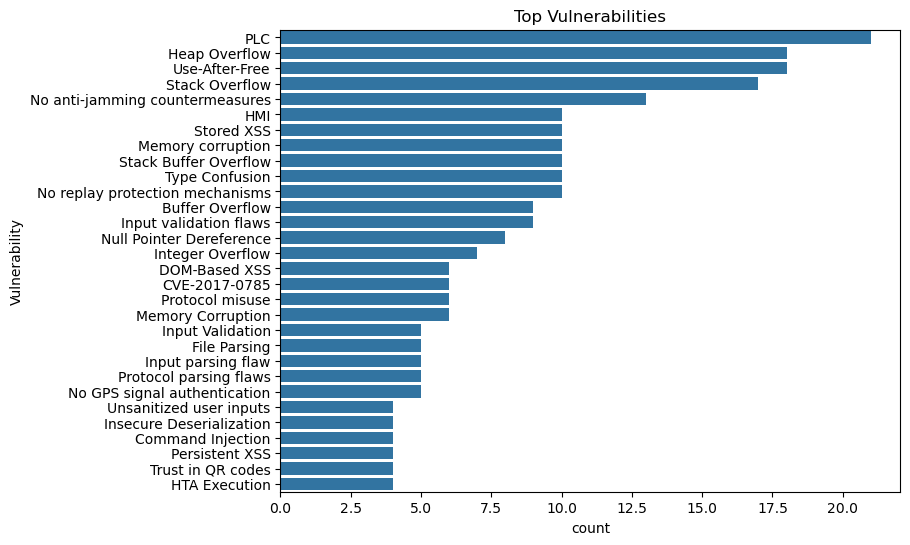

In [73]:
plt.figure(figsize=(8,6))
sns.countplot(
    y='Vulnerability',
    data=df,
    order=df['Vulnerability'].value_counts().index[:30]
)
plt.title("Top Vulnerabilities")
plt.show()

In [74]:
df.groupby(['Attack_Type'])[['Target_Type' , 'Detection_Method']].sum()

,Target_Type,Detection_Method
Attack_Type,,
--network=host Misuse,Host Network,"Packet captures, eBPF filters, netstat comparison"
.NET Assembly Obfuscation,AV-Protected Hosts,"Hook detection, behavior monitoring of Add-Typ..."
.NET Gadget Chain Injection,.NET Web Apps,"Deep packet inspection, custom protocol logs"
.NET ViewState Injection,ASP.NET Apps,"ViewState MAC enabled, anomaly request length"
.NET Web Shell (ASPX),Microsoft IIS with .NET support,"Look for .aspx uploads, command triggers, or s..."
...,...,...
tfstate in Git,GitHub Repo,"GitHub secret scanning, repo audits"
tmpfs Secrets Leak,Kubernetes Shared Volume,"Volume access logs (if enabled), runtime alerts"
vtable / IO Pointer Leak,C/C++ Service,Log scan for %p exposures; symbol scrubbing in...


In [75]:
df[['Category', 'Attack_Type', 'Impact']].describe()

,Category,Attack_Type,Impact
count,13927,13927,13927
unique,64,8775,13014
top,Insider Threat,Hardware Interface Exploitation,Credential theft
freq,560,161,36


In [76]:
df['Category'].value_counts()

Category
Insider Threat                                           560
Physical / Hardware Attacks                              543
Quantum Cryptography & Post-Quantum Threats              541
Malware & Threat                                         526
Wireless Attacks (Advanced)                              514
                                                        ... 
Automotive / CPS → Sensor Spoofing                         7
Automotive / CPS → Firmware Over-The-Air (FOTA) Abuse      5
Automotive / CPS → Physical Layer Attack                   3
Network security                                           2
 Mobile Security                                           1
Name: count, Length: 64, dtype: int64

Text(0.5, 1.0, 'Top 30 Security Categories')

d:\programs\anaonda\envs\myenvironment\Lib\site-packages\IPython\core\events.py:96: UserWarning: Glyph 128737 (\N{SHIELD}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
d:\programs\anaonda\envs\myenvironment\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128737 (\N{SHIELD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


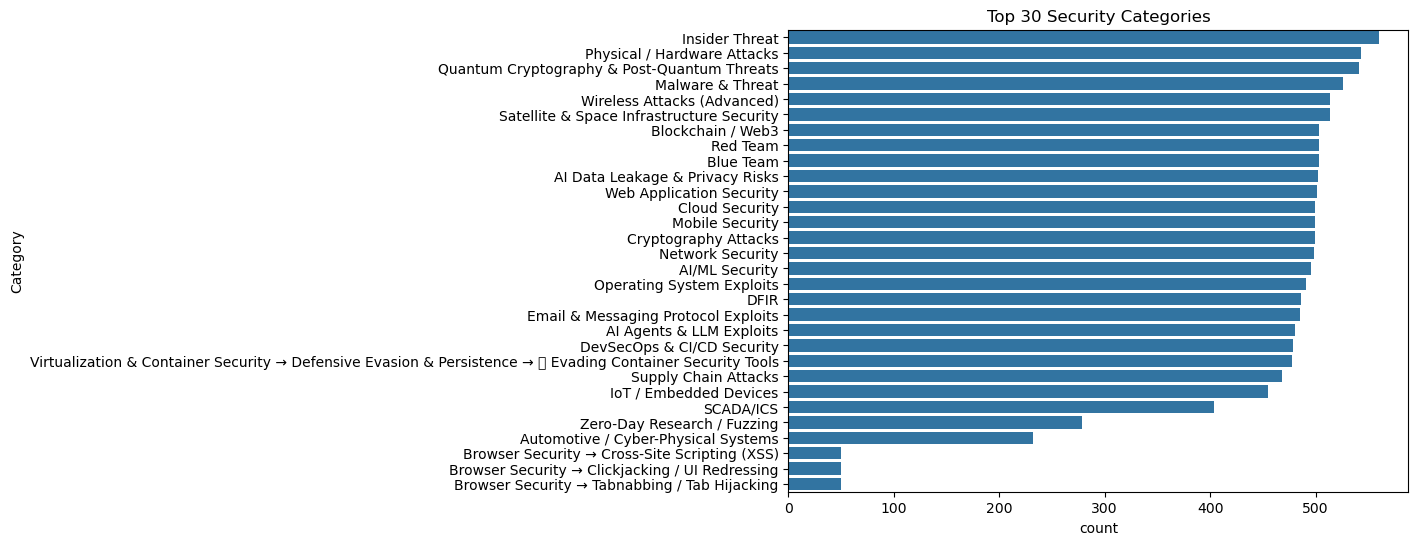

In [77]:
plt.figure(figsize=(8,6))
sns.countplot(y='Category' , data =df , order=df['Category'].value_counts().head(30).index)
plt.title('Top 30 Security Categories')

In [78]:
insider_df = df[df['Category'] == 'Insider Threat']

In [79]:
insider_df['Vulnerability'].value_counts().head(5)

Vulnerability
Social Engineering                    2
AutoRun Enabled USB ports             2
File Execution from Shared Folders    2
Macro Auto-Execution                  2
Misconfigured Task Scheduler          2
Name: count, dtype: int64

In [80]:
insider_df['Detection_Method'].value_counts().head(5)

Detection_Method
File access monitoring                  3
Endpoint USB Logging, AV Alerts         2
File Access Logs, Email Alerts          2
Email Gateway Filtering, Macro Alert    2
System Task Log Monitoring              2
Name: count, dtype: int64

In [81]:
# cross = pd.crosstab(df['Attack_Type'],df['Target_Type'])
# cross.iloc[:5,:5]

In [82]:
top_attacks = df['Attack_Type'].value_counts().nlargest(10).index
subset_df = df[df['Attack_Type'].isin(top_attacks)]
sub_cross = pd.crosstab(subset_df['Attack_Type'],subset_df['Target_Type'])
sub_cross

Target_Type,.NET Applications,".NET Builds, CI/CD",.NET CI Pipelines,".NET developers, Windows machines",ARM MCU,ATM,AWS IAM Roles,Access Control Panel,Access Control Systems,Air-gapped PCs,...,Zigbee IoT Device Batch,Zigbee Mesh PQ Devices,Zigbee QSM Devices,Zigbee QSM Nodes,Zigbee mesh networks,Zigbee-based IoT Device,Zigbee-enabled Quantum Edge Devices,Zoom,"bash`. Step 5: Since the app is root, these commands succeed — giving full system compromise. Step 6: Attacker may also install persistent backdoors or mine cryptocurrency silently. Step 7: Defender may not detect it unless system logs are carefully monitored.",cec-client -s -d 1` to power on the TV.Step 4: Send keypress sequences to navigate settings remotely.Step 5: Reconfigure network settings or install unauthorized apps.Step 6: Power off TV after changes to avoid suspicion.
Attack_Type,,,,,,,,,,,,,,,,,,,,,
Data Exfiltration,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
Dependency Confusion,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Fuzzer Configuration,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Hardware Interface Exploitation,0,0,0,0,1,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
Malicious Libraries,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Malicious Library,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Misuse of Legitimate Tools,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Privilege Escalation,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,2,0
Removable Media Attack,0,0,0,0,0,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0


<Axes: xlabel='Target_Type', ylabel='Attack_Type'>

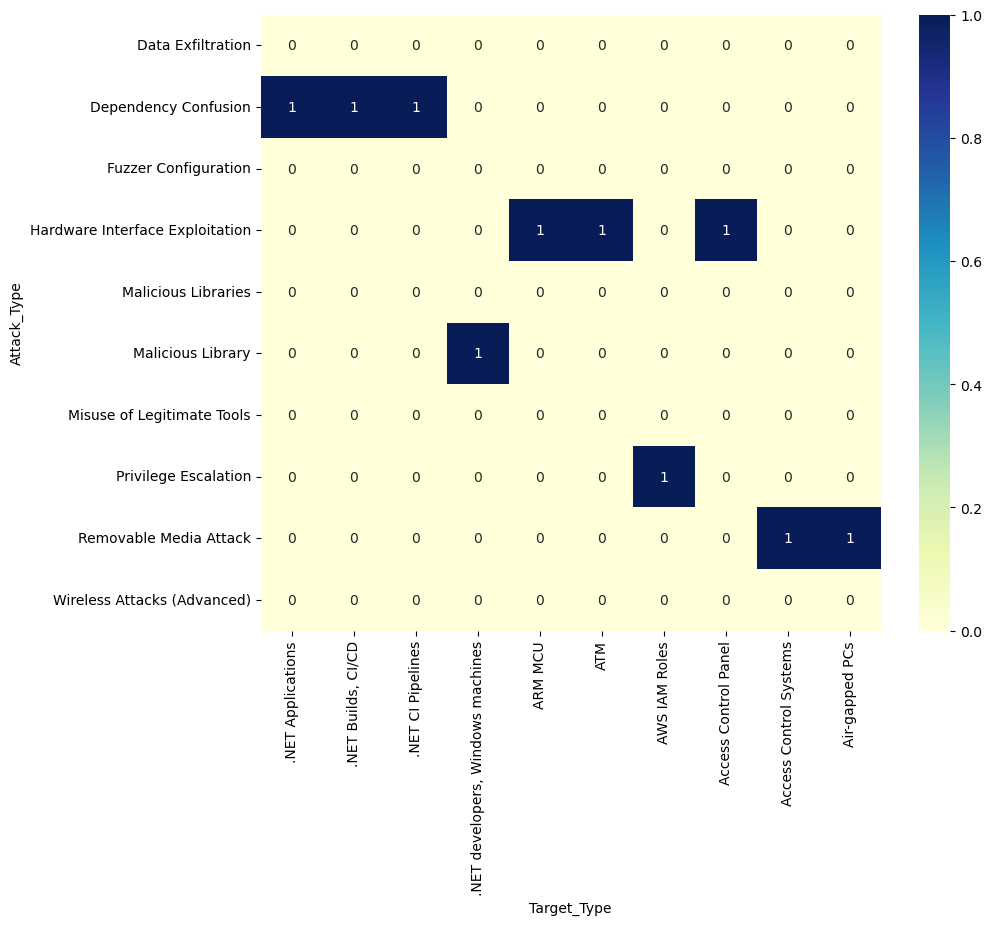

In [83]:
plt.figure(figsize=(10,8))
sns.heatmap(sub_cross.iloc[:,:10] , annot=True , cmap='YlGnBu' , fmt='d')

In [84]:
df['Impact'].value_counts()

Impact
Credential theft                  36
Credential Theft                  29
Remote Code Execution             25
Remote code execution             19
T0856                             18
                                  ..
Early spoof detection              1
Delayed response and data loss     1
Undetected threat chains           1
Vulnerable payloads or RCE         1
Varying cyber postures             1
Name: count, Length: 13014, dtype: int64

In [85]:
top_category = df['Category'].value_counts().nlargest(10).index
subset_df = df[df['Category'].isin(top_category)]
cross = pd.crosstab(subset_df['Category'] , subset_df['Impact'])
cross.iloc[:5,:5]


Impact,.txt open triggers macro executable,"2FA Bypass, Data Exposure",AD object mapping,AES or RSA key theft,AI Output Corruption
Category,,,,,
AI Data Leakage & Privacy Risks,0,0,0,0,0
Blockchain / Web3,0,0,0,0,0
Blue Team,1,0,0,0,0
Insider Threat,0,1,1,0,0
Malware & Threat,0,0,0,0,0


In [86]:
df['Tools_Used'].nunique()

12754

In [87]:
df['Tools_Used'].value_counts().head(10)

Tools_Used
Velociraptor                                        18
Remix IDE, Ganache, Metamask, Hardhat, ethers.js    17
KAPE                                                17
SDR, GPS Simulator                                  17
Burp Suite, Browser Dev Tools                       14
CMD                                                 14
Scapy, Wireshark                                    13
GRR Rapid Response                                  13
AFL++, libFuzzer                                    13
Browser, Burp Suite, sqlmap                         11
Name: count, dtype: int64

In [88]:
df['Target_Type'].value_counts(normalize=True) * 100

Target_Type
Windows                            2.089467
Workstation                        0.768292
Satellite                          0.560063
Endpoint                           0.359015
Android App                        0.330294
                                     ...   
Satellite OEM Firmware             0.007180
Simulated Satellite Telemetry      0.007180
Satellite Operators & SOC Teams    0.007180
Simulated Satellite Networks       0.007180
National Satellite Programs        0.007180
Name: proportion, Length: 9785, dtype: float64

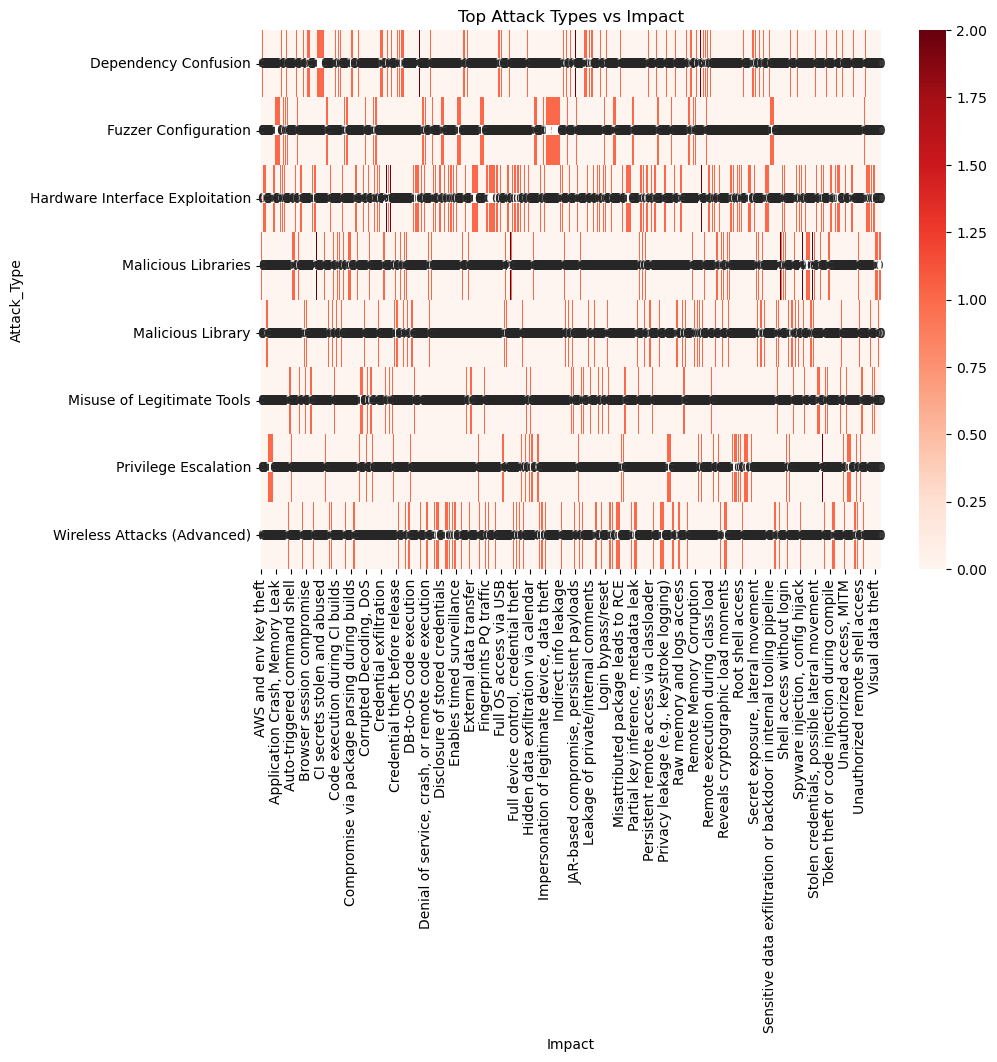

In [89]:
top_attacks = df['Attack_Type'].value_counts().nlargest(8).index
subset = df[df['Attack_Type'].isin(top_attacks)]

cross = pd.crosstab(subset['Attack_Type'], subset['Impact'])

plt.figure(figsize=(10,7))
sns.heatmap(cross, annot=True, cmap='Reds', fmt='d')
plt.title("Top Attack Types vs Impact")
plt.show()

In [90]:
df['Scenario_Length'] = df['Scenario_Description'].apply(len)
df['Solution_Length'] = df['Solution'].apply(len)

In [91]:
df[['Scenario_Length','Solution_Length']].describe()

,Scenario_Length,Solution_Length
count,13927.000000,13927.000000
mean,128.009909,63.264881
std,91.440142,38.203041
min,30.000000,9.000000
25%,79.000000,38.000000
50%,104.000000,51.000000
75%,143.000000,83.000000
max,795.000000,520.000000


In [92]:
complexity_impact = pd.crosstab(
    pd.qcut(df['Scenario_Length'], 4) ,
    df['Impact']
)
complexity_impact

Impact,- Access to unauthorized VLANs- Bypass segmentation- Lateral movement opportunities,- Access unauthorized admin/content- Tenant data leaks- Privilege escalation,- Account Takeover- Full access to user account- Violation of security trust,- Account Takeover- Unauthorized access- Identity theft- Loss of customer trust,- Account deletion or tampering- Role escalation- Silent configuration change- Data loss or exposure,- Account hacked- Sensitive data stolen- Email or financial access- Identity theft- Escalation to internal network compromise,- Account hijack- Password or settings changed- Email changed- Private data leaked- Silent actions from WebView,- Account hijack- Personal data theft- Unwanted posts or messages- Financial loss (if banking/app access)- Scams sent to user’s contacts,- Account hijack- Profile tampering- Unauthorized password/email change- Data deletion or leakage- Admin-level access compromise,- Account takeover- API abuse- Data leakage- Broken authentication,...,"• Complete lateral movement from single entry point• Spread of malware or backdoors across environment• Full control of systems via PowerShell• Dumping of hashes, tokens, and secrets remotely","• Enables phishing or malware via trusted domain• Social engineering becomes more convincing• Potential credential theft, reputation loss","• Full control of trusted subdomain• Hosting phishing, malware, defacement• Inject malicious scripts in web pages using the domain",• Full remote access with Meterpreter• Drop of persistent backdoors• Total takeover of Windows host• Possible lateral movement and domain compromise,"• Persistent/Reflected XSS → data theft- Malware injection, session hijacking- Brand trust loss, site defacement","• Phishing, malware spread via trusted domain- XSS via javascript: payload- Brand trust and session security compromised","• Reflected XSS, data theft, malware injection• Phishing using legitimate domain• Session token exfiltration",• Victims sent to phishing/evil sites- Brand trust eroded- Possible follow-up attacks,✅ Password changed✅ Email or settings changed✅ Data sent or deleted✅ You get locked out✅ Attacker gets access,➤ Root shell from unprivileged user➤ Full takeover without code signing➤ Works in containers or local shells➤ No file-system modifications
Scenario_Length,,,,,,,,,,,,,,,,,,,,,
"(29.999, 79.0]",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
"(79.0, 104.0]",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
"(104.0, 143.0]",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
"(143.0, 795.0]",1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1


In [93]:
top_impacts = df['Impact'].value_counts().nlargest(10).index

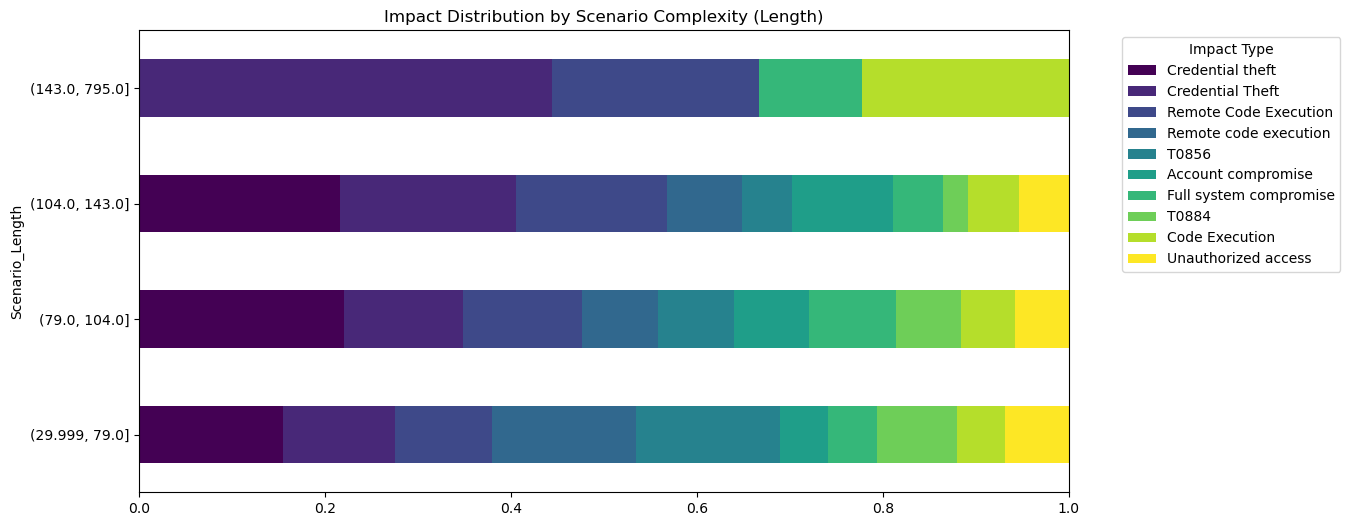

In [94]:
complexity_impact_pct = complexity_impact[top_impacts].div(complexity_impact[top_impacts].sum(axis=1), axis=0)

complexity_impact_pct.plot(kind='barh', stacked=True, figsize=(12, 6), colormap='viridis')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Impact Type')
plt.title('Impact Distribution by Scenario Complexity (Length)')
plt.show()

In [95]:
df.groupby('Attack_Type')['Scenario_Length'].mean().sort_values(ascending=False).head()

Attack_Type
Over-Permissive Role Assignment to Insecure Identity              795.0
Local File Inclusion (LFI) via Deep Link + WebView                791.0
Hardware-Based Side Channel Attack (Acoustic Emission Leakage)    789.0
Exploitation via Known Vulnerable SDK Versions                    766.0
Local File Inclusion (LFI) + Path Traversal                       761.0
Name: Scenario_Length, dtype: float64

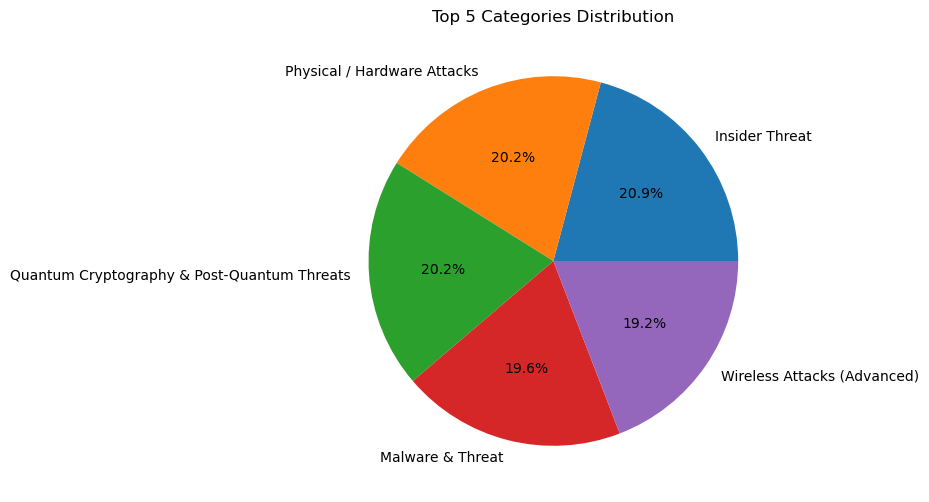

In [96]:
top_cat = df['Category'].value_counts().head(5)

plt.figure(figsize=(6,6))
plt.pie(top_cat, labels=top_cat.index, autopct='%1.1f%%')
plt.title("Top 5 Categories Distribution")
plt.show()

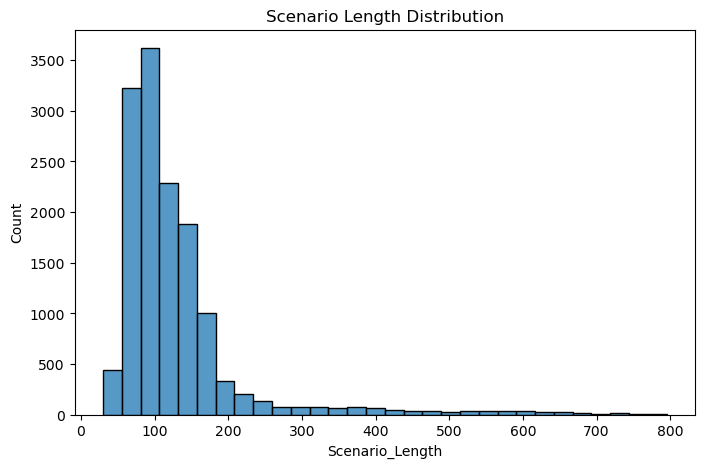

In [97]:
plt.figure(figsize=(8,5))
sns.histplot(df['Scenario_Length'], bins=30)
plt.title("Scenario Length Distribution")
plt.show()

d:\programs\anaonda\envs\myenvironment\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128737 (\N{SHIELD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


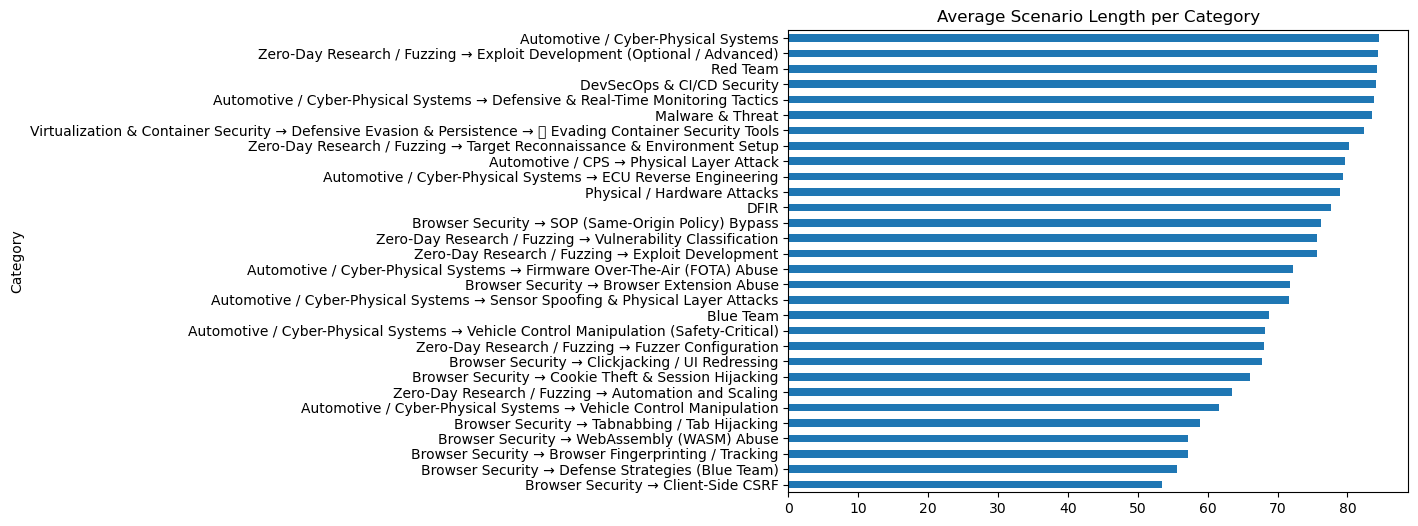

In [98]:
df.groupby('Category')['Scenario_Length'].mean().sort_values().head(30).plot(kind='barh', figsize=(8,6))
plt.title("Average Scenario Length per Category")
plt.show()

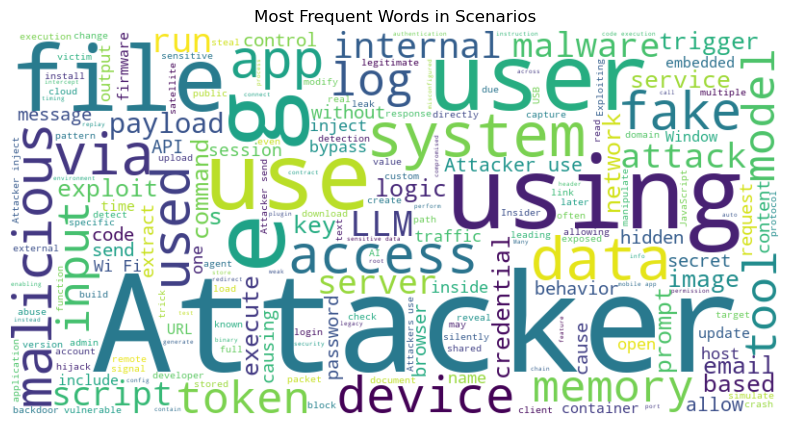

In [99]:
text = " ".join(df['Scenario_Description'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Most Frequent Words in Scenarios")
plt.show()

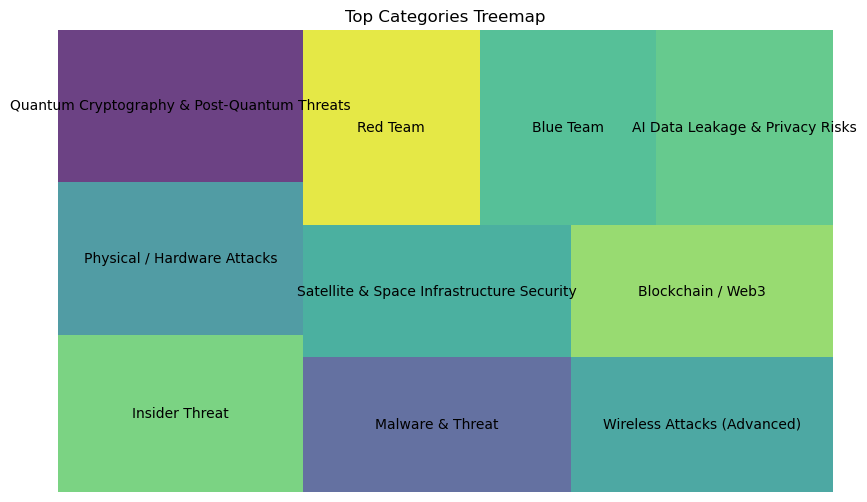

In [100]:
top_cat = df['Category'].value_counts().head(10)

plt.figure(figsize=(10,6))
squarify.plot(
    sizes=top_cat.values,
    label=top_cat.index,
    alpha=0.8
)

plt.axis('off')
plt.title("Top Categories Treemap")
plt.show()

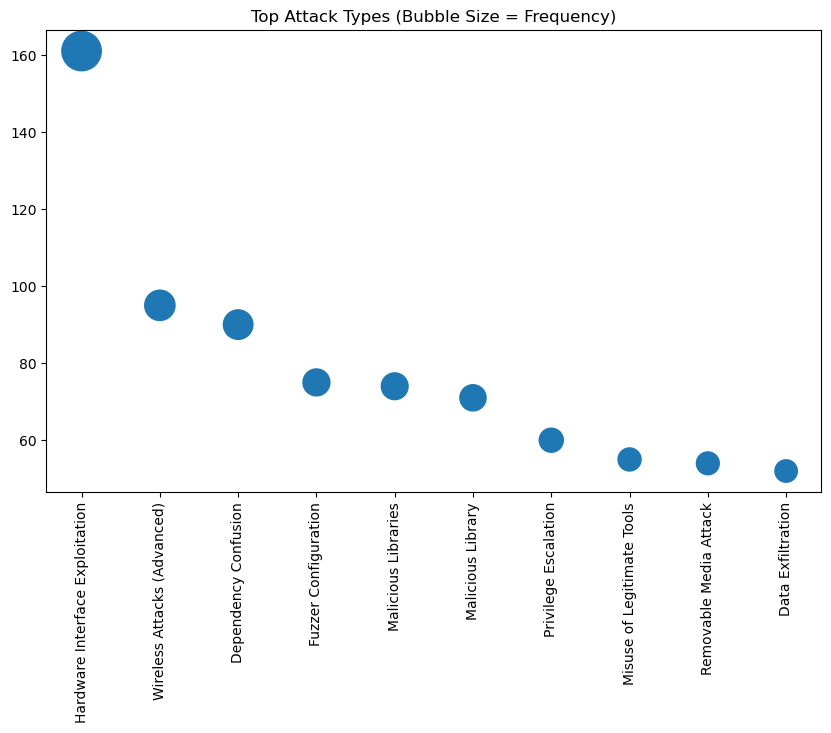

In [101]:
attack_counts = df['Attack_Type'].value_counts().head(10)

plt.figure(figsize=(10,6))
plt.scatter(
    attack_counts.index,
    attack_counts.values,
    s=attack_counts.values * 5
)

plt.xticks(rotation=90)
plt.title("Top Attack Types (Bubble Size = Frequency)")
plt.show()

## save data into excel file

In [102]:
df.to_excel('Attack.xlsx',index=False)